In [2]:
import pandas as pd
import matplotlib.pyplot as plt

matches = pd.read_csv("archive (3)/matches.csv")
deliveries = pd.read_csv("archive (3)/deliveries.csv")

print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)

Matches: (1095, 20)
Deliveries: (260920, 17)


In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
print("matches columns:", matches.columns.tolist())
print("deliveries columns :", deliveries.columns.tolist())

matches columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
deliveries columns : ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [7]:
print("missing values in matches: ")
print(matches.isnull().sum())

missing values in matches: 
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [11]:
matches.fillna("unknown",inplace =True)
deliveries.fillna(0,inplace = True)
print(" matches missing value:", matches.isnull().sum().sum())
print("deliveries missing value :", deliveries.isnull().sum().sum())

 matches missing value: 0
deliveries missing value : 0


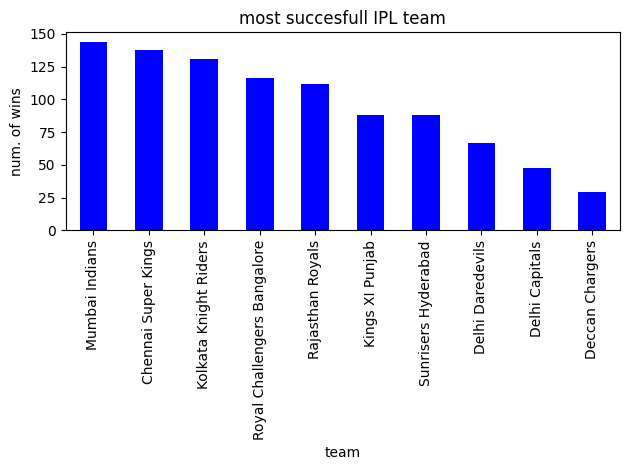

In [15]:
matches["winner"].value_counts().head(10).plot(kind = "bar", color = "blue")
plt.title("most succesfull IPL team")
plt.xlabel("team")
plt.ylabel("num. of wins")
plt.tight_layout()
plt.show()

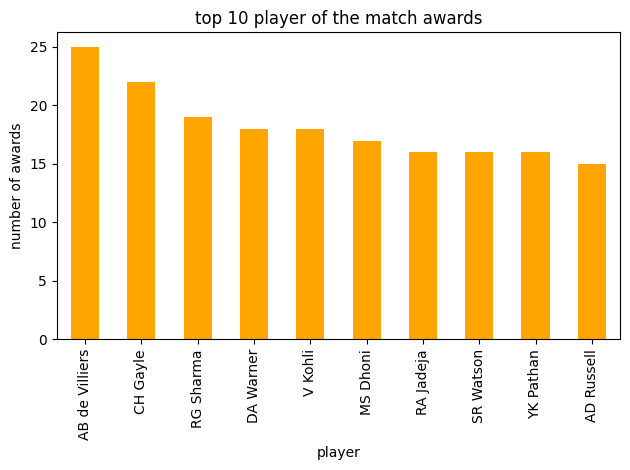

In [17]:
matches["player_of_match"].value_counts().head(10).plot(kind = "bar", color = "orange")
plt.title("top 10 player of the match awards")
plt.xlabel("player")
plt.ylabel("number of awards")
plt.tight_layout()
plt.show()

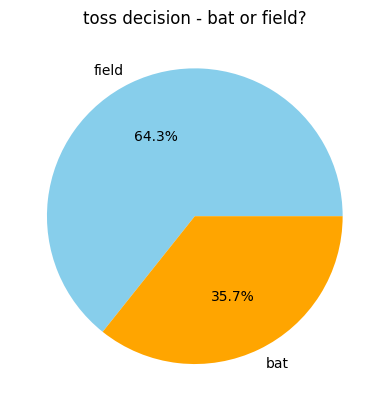

In [18]:
matches["toss_decision"].value_counts().plot(kind = "pie", autopct = "%1.1f%%", colors = ["skyblue", "orange"])
plt.title("toss decision - bat or field?")
plt.ylabel("")
plt.show()

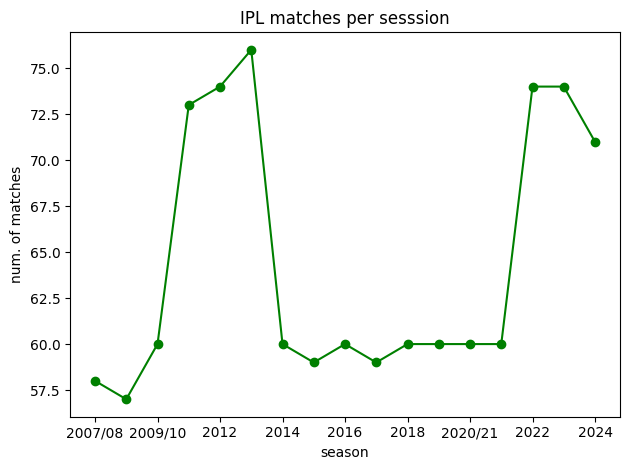

In [19]:
matches.groupby("season")["winner"].count().plot(kind = "line", color = "green", marker = "o")
plt.title("IPL matches per sesssion")
plt.xlabel("season")
plt.ylabel("num. of matches")
plt.tight_layout()
plt.show()

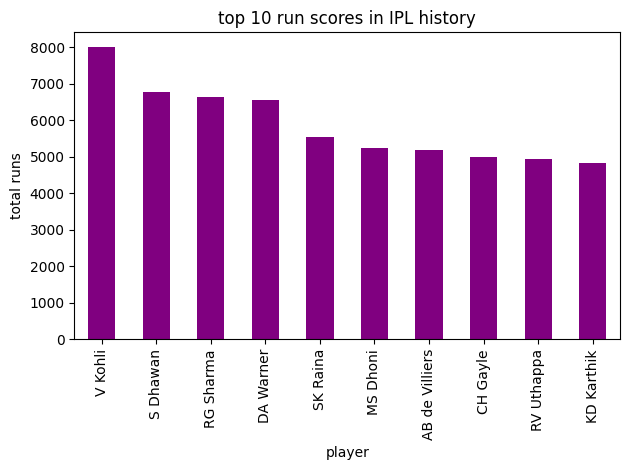

In [24]:
deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending = False).head(10).plot(kind ="bar", color = "purple")
plt.title("top 10 run scores in IPL history")
plt.xlabel("player")
plt.ylabel("total runs")
plt.tight_layout()
plt.show()

## IPL Data Analysis - Key Findings

### Dataset
- 1,095 IPL matches analyzed
- 2,60,920 balls bowled analyzed

### Key Insights
1. Mumbai Indians are the most successful IPL team
2. Virat Kohli is the highest run scorer in IPL history
3. Most teams prefer to field after winning the toss
4. IPL grew significantly in matches per season over the years
5. Top players consistently win Player of the Match awards

### Tools Used
- Python
- Pandas
- Matplotlib

In [27]:
top_scorers = deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10).reset_index()
top_scorers.columns = ["Player", "Total Runs"]
top_scorers.to_excel("ipl_top_scorers.xlsx", index=False)
print("Excel file saved!")

Excel file saved!
